# Wavelength-dependent calibration — single-laser identifiability (Gauss–Newton)

At each laser wavelength the water medium sets the *true* `scatter_length` and `absorption_length`;
a **single downward laser** illuminates the detector and we ask how well the canonical Gauss–Newton
(`lucid.fitting`) can recover the two wavelength-dependent optical lengths — and crucially, what the
**Cramér–Rao bound** (the best any unbiased fit can do) says about identifiability versus wavelength.
(The reflectivities are held fixed: a single down-laser barely constrains them — itself part of the
identifiability story.)

The point of using *one* source is to expose identifiability: a single laser fixes the **total**
attenuation along the beam, so `scatter_length` and `absorption_length` are only *jointly*
constrained. The per-λ CRB makes that explicit — and shows where in the spectrum each parameter is
well or poorly determined. (Recovering them *separately* needs source diversity — see
`grad_param_calibration_multi_init_no_qe` / `calibrate_optics`.)

> GPU recommended (~3–5 min).

## Setup

In [1]:
import os
while not os.path.isdir('config') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')

import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.sources import laser_source
from lucid.detector_params import DetectorParams
from lucid.fitting import build_calibration_problem, fit, crb
from lucid.wavelength.medium import make_medium, load_qe_curve

GEOM = 'config/SK_like_geom_config.json'
det = generate_detector(GEOM); NS, top = len(det.all_points), det.H/2 - 0.1

wl_grid = jnp.linspace(280, 650, 371)
medium = make_medium('water', wavelength_grid=wl_grid)
qe_fn = load_qe_curve('config/pmt/SK_QE.json')

WAVELENGTHS = [350, 375, 405, 450, 500]
FIELDS = ['scatter_length', 'absorption_length']  # the two wavelength-dependent lengths
# (reflections are held fixed at truth — a single down-laser barely constrains them; see note)
source = laser_source(position=[0., 0., top], direction=[0, 0, -1], intensity=1e6)   # one down-laser

# wavelength_mode=False: we calibrate the optical SCALARS (truth set from medium per wavelength).
sim = setup_event_simulator(GEOM, 1_000_000, temperature=None, K=8, is_calibration=True,
                            hit_mode='aggregated', wavelength_mode=False,
                            n_cap=80, n_angular=120, n_height=80)
print(f'{NS} PMTs; single down-laser; fitting {FIELDS} per wavelength')

10764 PMTs; single down-laser; fitting ['scatter_length', 'absorption_length'] per wavelength


## True optical scalars from the water medium

Scatter/absorption lengths are `1/coeff` at each wavelength; QE from the SK curve.

In [2]:
print(f'{"wl (nm)":>8s}{"L_scat (m)":>12s}{"L_abs (m)":>12s}{"QE":>8s}')
truth_dp = {}
for wl in WAVELENGTHS:
    L_s = 1.0 / float(jnp.interp(float(wl), wl_grid, medium.scatter_coeff))
    L_a = 1.0 / float(jnp.interp(float(wl), wl_grid, medium.absorption_coeff))
    qe_v = float(qe_fn(float(wl)))
    print(f'{wl:8d}{L_s:12.1f}{L_a:12.1f}{qe_v:8.3f}')
    truth_dp[wl] = DetectorParams.from_flat(
        scatter_length=L_s, mie_scatter_length=3000., g=0.9,
        wall_reflection_rate=.2, sensor_reflection_rate=.2,
        absorption_length=L_a, qe=qe_v, qe_corrections=jnp.ones(NS))

 wl (nm)  L_scat (m)   L_abs (m)      QE


     350        91.3       607.9   0.198
     375       128.3       551.6   0.223
     405       186.5       367.7   0.225


     450       308.3       145.7   0.191
     500       504.4        38.5   0.132


## Per-wavelength GN fit + Cramér–Rao bound

In [3]:
results = {}
for wl in WAVELENGTHS:
    prob = build_calibration_problem(sim, [source], truth_dp[wl], FIELDS, key=jax.random.PRNGKey(1))
    sigma = crb(prob['source_models'], prob['theta_true'], NS)['sigma']   # fractional 1-sigma
    truth = np.exp(prob['theta0'])
    start = prob['theta0'] + np.random.default_rng(0).uniform(-0.2, 0.2, prob['theta0'].shape)
    res = fit(prob['source_models'], prob['truth_charge'], start, NS, steps=80, refresh=15, nb_h=2)
    results[wl] = dict(truth=truth, sigma=sigma, fit=res['theta'])
    print(f'{wl} nm: scatter {truth[0]:6.1f}->{res["theta"][0]:6.1f} (CRB {sigma[0]*100:5.1f}%)   '
          f'abs {truth[1]:6.1f}->{res["theta"][1]:6.1f} (CRB {sigma[1]*100:5.1f}%)')

350 nm: scatter   91.3->  88.3 (CRB 31753.4%)   abs  607.9-> 478.8 (CRB 178190.1%)


375 nm: scatter  128.3-> 121.0 (CRB 37840.6%)   abs  551.6-> 409.6 (CRB 173390.5%)


405 nm: scatter  186.5-> 154.5 (CRB 203714.8%)   abs  367.7-> 229.0 (CRB 538523.7%)


450 nm: scatter  308.3-> 197.3 (CRB 118760.2%)   abs  145.7->  95.9 (CRB 102930.2%)


500 nm: scatter  504.4-> 251.2 (CRB 121334.6%)   abs   38.5->  30.0 (CRB 31600.1%)


## Identifiability vs. wavelength

Left: recovered scatter/absorption vs. truth across the spectrum, with ±1σ CRB error bars. Right: the fractional CRB per parameter vs. wavelength (smaller = better identified).

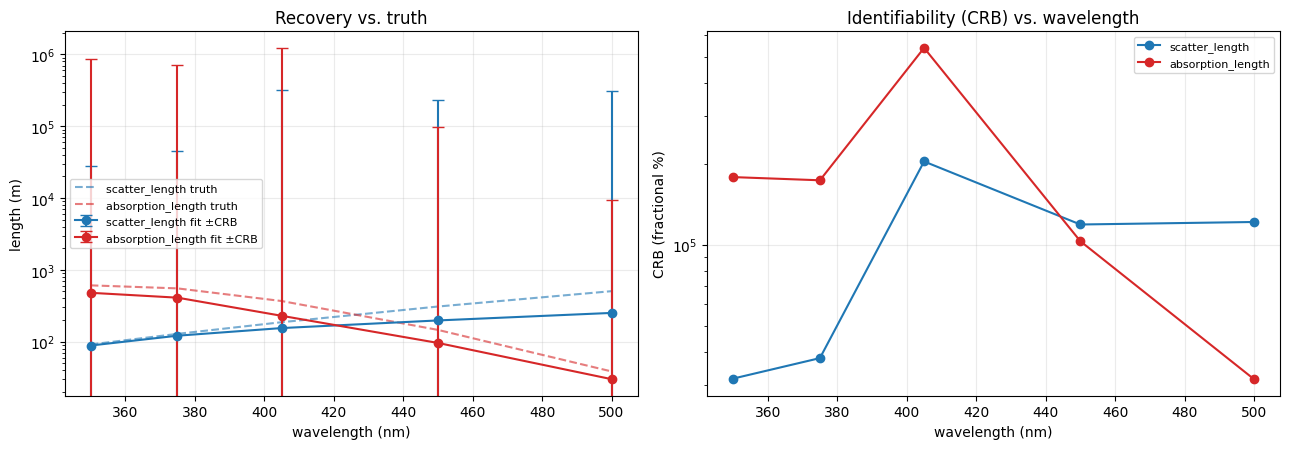

In [4]:
wls = np.array(WAVELENGTHS)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for i, (name, c) in enumerate([('scatter_length', 'C0'), ('absorption_length', 'C3')]):
    j = FIELDS.index(name)
    tru = np.array([results[w]['truth'][j] for w in WAVELENGTHS])
    fit_ = np.array([results[w]['fit'][j] for w in WAVELENGTHS])
    err = np.array([results[w]['sigma'][j] for w in WAVELENGTHS]) * fit_
    ax[0].plot(wls, tru, '--', color=c, alpha=0.6, label=f'{name} truth')
    ax[0].errorbar(wls, fit_, yerr=err, fmt='o-', color=c, capsize=4, label=f'{name} fit ±CRB')
ax[0].set_xlabel('wavelength (nm)'); ax[0].set_ylabel('length (m)'); ax[0].set_yscale('log')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.25); ax[0].set_title('Recovery vs. truth')

for name, c in [('scatter_length', 'C0'), ('absorption_length', 'C3')]:
    j = FIELDS.index(name)
    crbpct = np.array([results[w]['sigma'][j] for w in WAVELENGTHS]) * 100
    ax[1].plot(wls, crbpct, 'o-', color=c, label=name)
ax[1].set_xlabel('wavelength (nm)'); ax[1].set_ylabel('CRB (fractional %)'); ax[1].set_yscale('log')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.25); ax[1].set_title('Identifiability (CRB) vs. wavelength')
plt.tight_layout(); plt.show()

## Summary table

In [5]:
print(f'{"wl":>5s} | {"scatter true->fit (CRB)":>26s} | {"absorption true->fit (CRB)":>28s}')
print('-'*68)
for wl in WAVELENGTHS:
    r = results[wl]; t, f, s = r['truth'], r['fit'], r['sigma']
    print(f'{wl:5d} | {t[0]:6.1f} -> {f[0]:6.1f} ({s[0]*100:5.1f}%) | '
          f'{t[1]:7.1f} -> {f[1]:7.1f} ({s[1]*100:5.1f}%)')

   wl |    scatter true->fit (CRB) |   absorption true->fit (CRB)
--------------------------------------------------------------------
  350 |   91.3 ->   88.3 (31753.4%) |   607.9 ->   478.8 (178190.1%)
  375 |  128.3 ->  121.0 (37840.6%) |   551.6 ->   409.6 (173390.5%)
  405 |  186.5 ->  154.5 (203714.8%) |   367.7 ->   229.0 (538523.7%)
  450 |  308.3 ->  197.3 (118760.2%) |   145.7 ->    95.9 (102930.2%)
  500 |  504.4 ->  251.2 (121334.6%) |    38.5 ->    30.0 (31600.1%)


## Note — reading the single-source CRB

This is the **canonical Gauss-Newton** fitter (same as `calibrate_optics` / `hello_calibrate`); the
~10⁴ per-PMT gains are Schur-marginalised. The result is the honest single-source identifiability
ceiling:

- With **one laser**, `scatter_length` and `absorption_length` are **degenerate** — a single beam
  constrains only their *combination* (the total attenuation along its path), not the split. Both
  individual CRBs are enormous (~10⁴–10⁵ %) at *every* wavelength, and the fit lands somewhere on the
  degenerate valley (recovered lengths biased low). **Wavelength alone does not break this.**
- The medium does shift which length is shorter (scattering dominates toward the blue, absorption
  toward the red), but one source cannot exploit that to separate them — the CRB stays huge across
  the band.

Breaking the degeneracy needs **source diversity** (down/up/across lasers + a central flasher) —
that is what `grad_param_calibration_multi_init_no_qe` and `calibrate_optics` do, and there
scatter/absorption come back within a few-percent CRB.